In [2]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver


print("=" * 60)
print("VQE for N2 Molecule on simulator")
print("=" * 60)

# ---- Step 1: Generate N2 Hamiltonian ----
print("\n[1/5] Generating N2 Hamiltonian...")
driver = PySCFDriver(atom='N 0 0 0; N 0 0 1.098', basis='sto3g')
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"  ✓ Number of qubits: {hamiltonian.num_qubits}")
print(f"  ✓ Number of Pauli terms: {len(hamiltonian)}")

VQE for N2 Molecule on simulator

[1/5] Generating N2 Hamiltonian...
  ✓ Number of qubits: 20
  ✓ Number of Pauli terms: 2951


In [ ]:
from scipy.sparse.linalg import eigsh

# Sparse reprezentace
hamiltonian_sparse = hamiltonian.to_matrix(sparse=True)

# Najdi nejnižší vlastní hodnotu
eigenvalues, eigenvectors = eigsh(hamiltonian_sparse, k=1, which='SA')
ground_state_energy = eigenvalues[0]

print(f"Ground state energy: {ground_state_energy} Ha")
print(f"Ground state vector shape: {eigenvectors.shape}")

In [2]:
# Nuclear repulsion energy for N2 at 1.098 Å
Z_N = 7  # Atomic number from periodic table
R = 1.098  # Å
R_bohr = R * 1.88973  # Conversion: 1 Å = 1.88973 Bohr
E_nuc = (Z_N * Z_N) / R_bohr  # Nuclear repulsion energy in Ha

print(f"  ✓ Nuclear repulsion energy: {E_nuc:.6f} Ha")

  ✓ Nuclear repulsion energy: 23.615328 Ha


In [ ]:
expected_energy = ground_state_energy + E_nuc
print(f"  ✓ Expected total energy: {expected_energy:.6f} Ha")

In [3]:
expected_total_energy=-107.653048 

In [3]:
# Create Hartree-Fock initial state
from qiskit_nature.second_q.circuit.library import HartreeFock

hf_state = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)


This circuit has  40 parameters


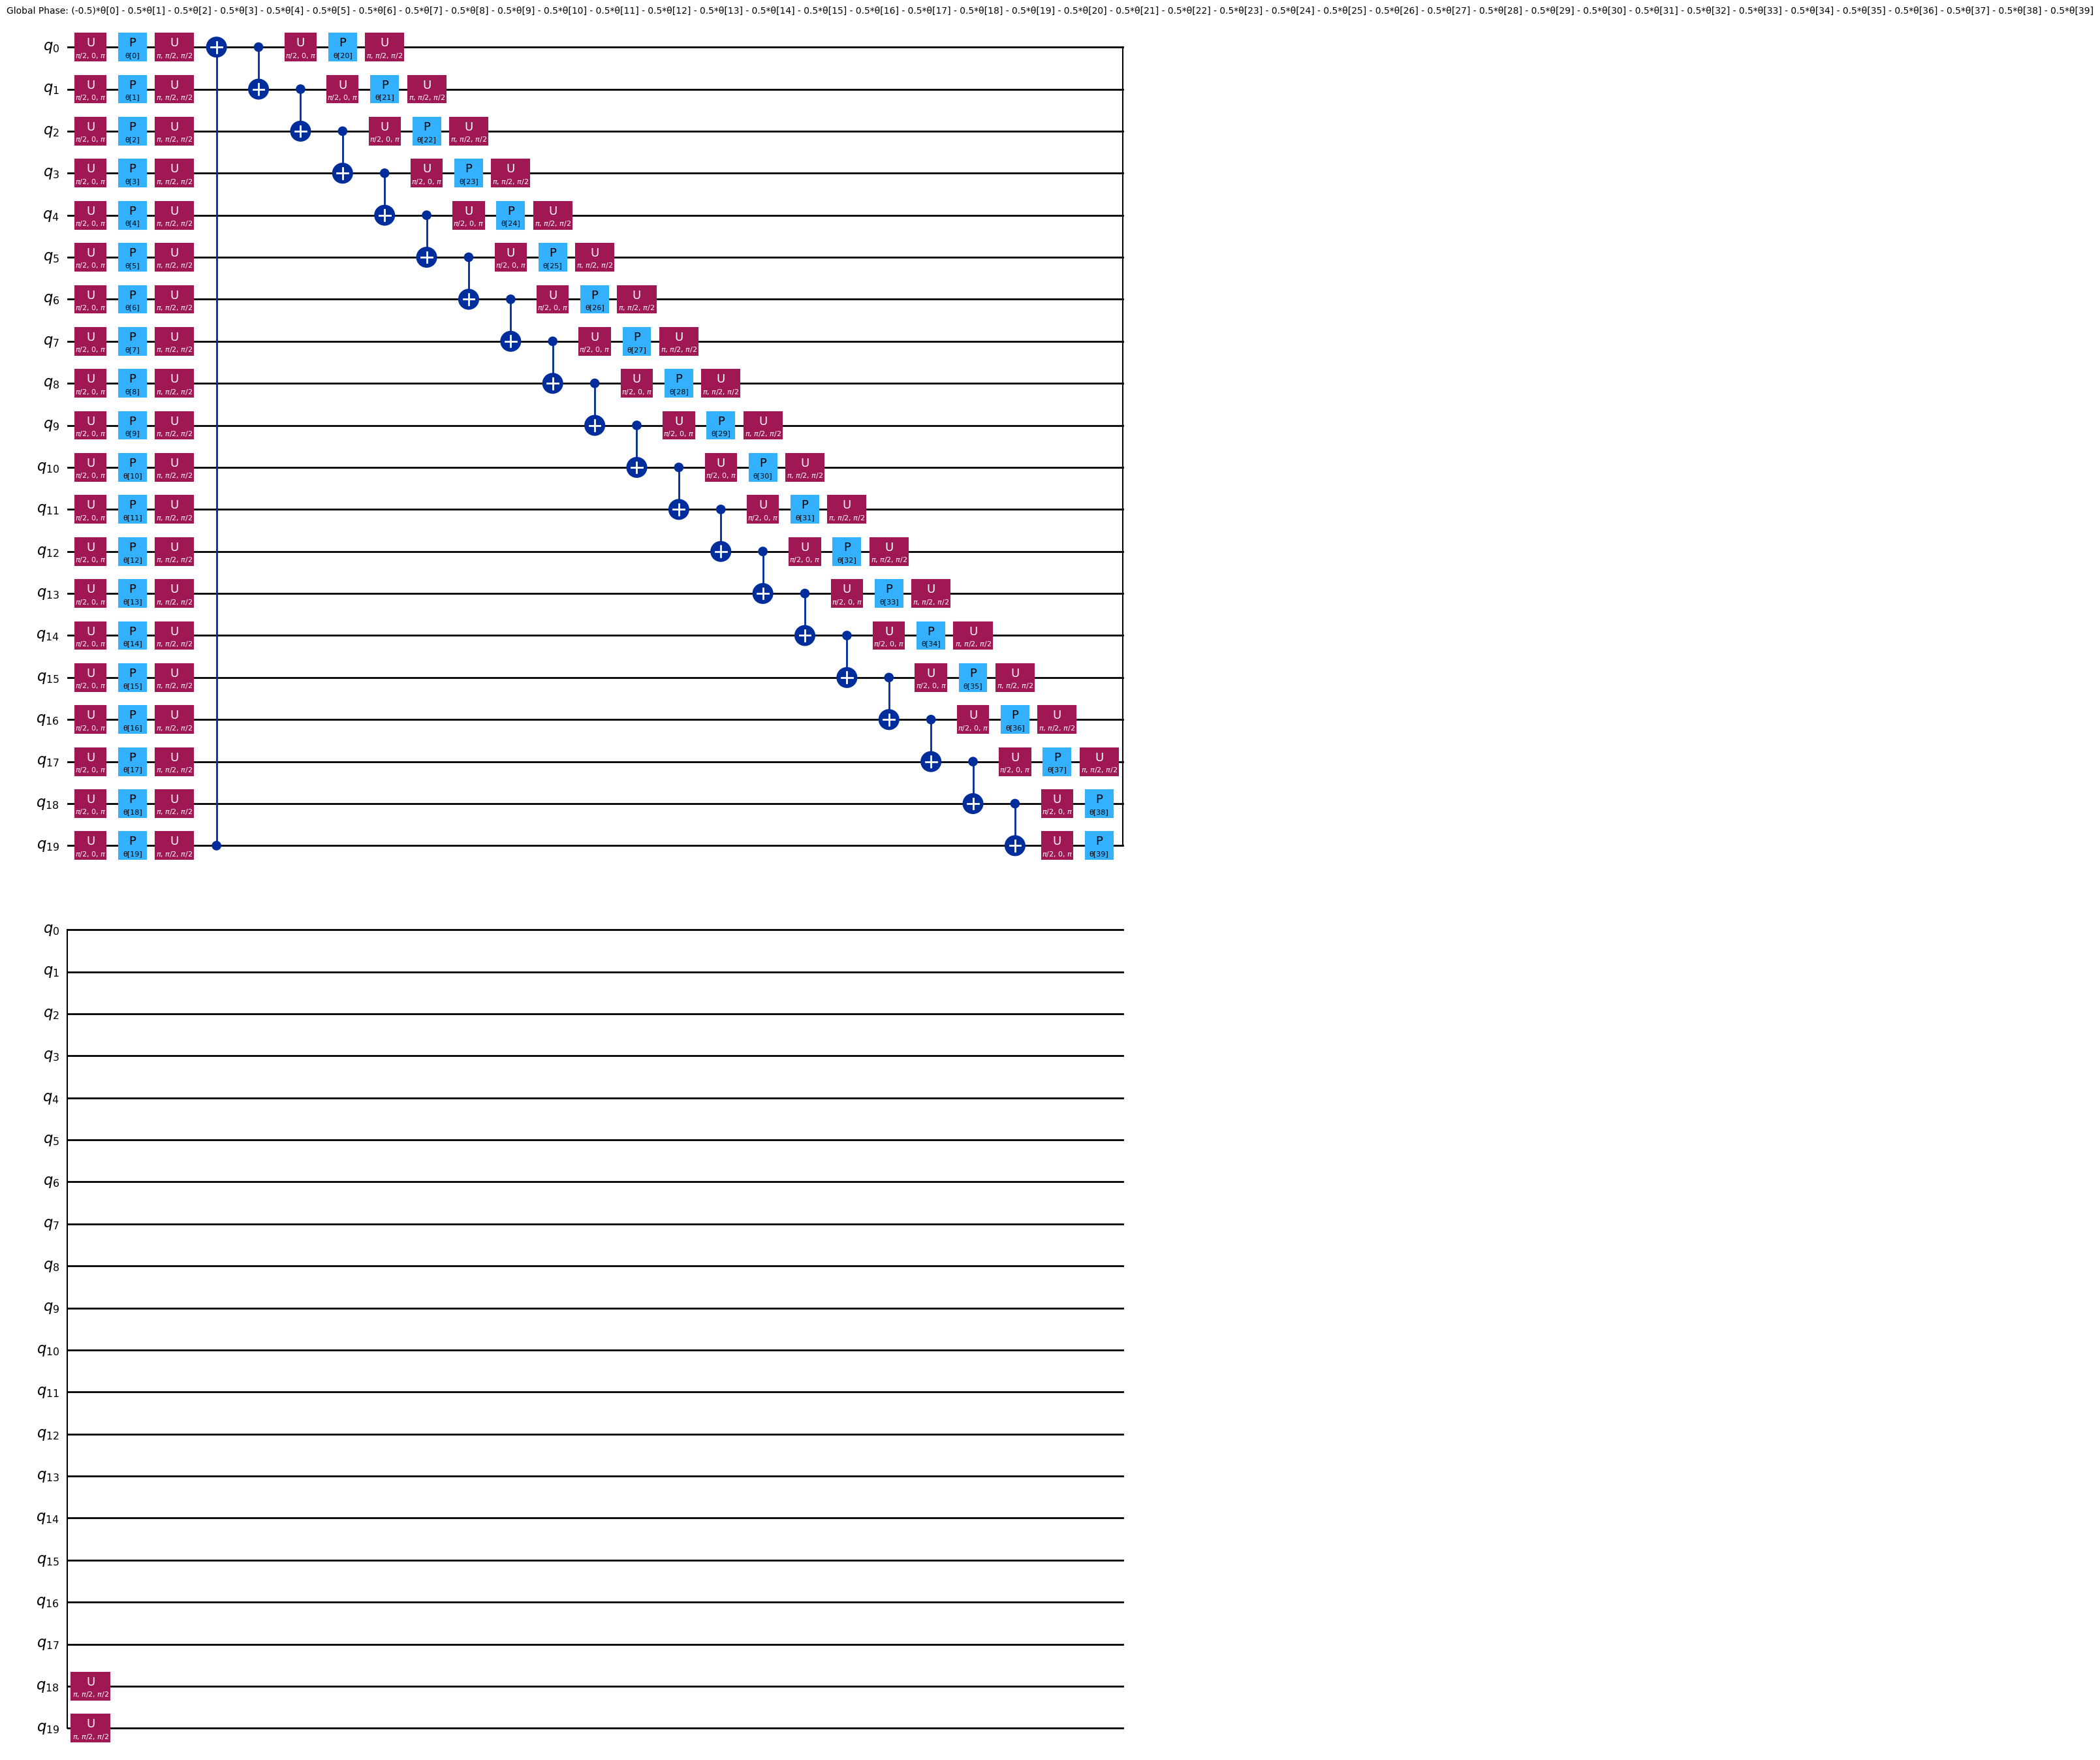

In [4]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [ ]:
from scipy.optimize import minimize
import numpy as np

import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


from methods.methods import cost_function


iterations = [0]
file_name = "n2-one-rep.csv"
initial_params = np.zeros(ansatz.num_parameters)

print("Optimizing parameters...")
result = minimize(
    fun=cost_function, 
    x0=initial_params, 
    args=(problem, hamiltonian, ansatz, file_name, iterations),
    method='COBYLA', 
    options={"maxiter": 20_000}
)

print("-" * 30)
print(f"Optimized energy: {result.fun:.6f} Ha")
print(f"Expected:         {expected_total_energy} Ha")


Optimizing parameters...
Iteration 1: Evaluating cost function...
  Energy: -98.369681 Ha
Iteration 2: Evaluating cost function...
  Energy: -95.918373 Ha
Iteration 3: Evaluating cost function...
  Energy: -92.924219 Ha
Iteration 4: Evaluating cost function...
  Energy: -95.896355 Ha
Iteration 5: Evaluating cost function...
  Energy: -99.044903 Ha
Iteration 6: Evaluating cost function...
  Energy: -99.675577 Ha
Iteration 7: Evaluating cost function...
  Energy: -100.253015 Ha
Iteration 8: Evaluating cost function...
  Energy: -100.774739 Ha
Iteration 9: Evaluating cost function...
  Energy: -101.373657 Ha
Iteration 10: Evaluating cost function...
  Energy: -101.910492 Ha
Iteration 11: Evaluating cost function...
  Energy: -102.597020 Ha
Iteration 12: Evaluating cost function...
  Energy: -99.710995 Ha
Iteration 13: Evaluating cost function...
  Energy: -96.298891 Ha
Iteration 14: Evaluating cost function...
  Energy: -99.346368 Ha
Iteration 15: Evaluating cost function...
  Energy: -10

NameError: name 'expected_energy' is not defined

In [10]:
from methods.methods import plot_convergence, compute_error
print("-" * 30)
print(f"Optimized energy: {result.fun:.6f} Ha")
print(f"Expected:         {expected_total_energy} Ha")
print(f"Error: {compute_error(result.fun, expected=expected_total_energy):.2f}%")

------------------------------
Optimized energy: -106.760276 Ha
Expected:         -107.653048 Ha
Error: 0.83%


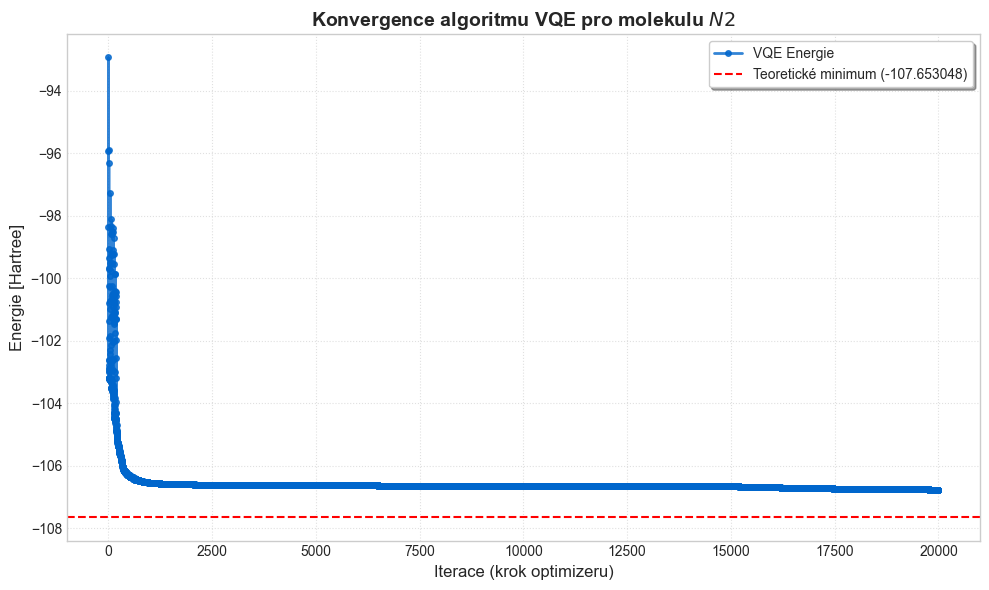

In [12]:
plot_convergence(file_name, "N2", expected_total_energy)

In [3]:
hf_benchmark = problem.reference_energy
print(f"Hartree-Fock benchmark energy: {hf_benchmark:.6f} Ha")

Hartree-Fock benchmark energy: -107.495975 Ha
